58033
(55, 55, 3)


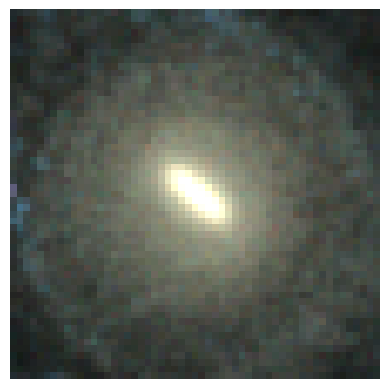

In [ ]:
import pest
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = False

ds = pest.FitsDataset("/urz/gpuscratch/its/doserbd/data/SKIRT_synthetic_images/fits")
print(len(ds))

# Problematic cases:
# 1: Ellipse is not well defined
# 55555: Rotational edge is visible

image = ds[55555].transpose(1, 2, 0)
print(image.shape)

plt.imshow(image)
plt.axis("off")
plt.show()

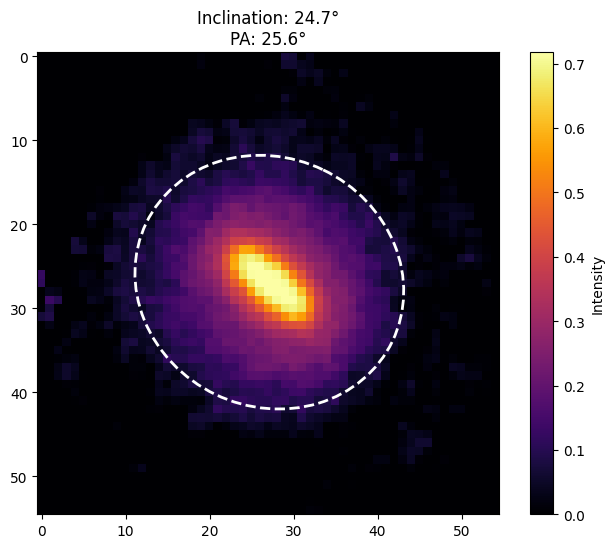

In [82]:
stats = pest.estimate_geometry_weighted(image)
pest.visualize_results(stats)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.023447760334539].


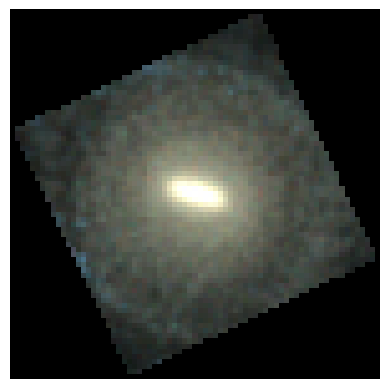

In [83]:
rotated_image = pest.align_image_horizontally(image, stats["pa_rad"])
plt.imshow(rotated_image)
plt.axis("off")
plt.show()

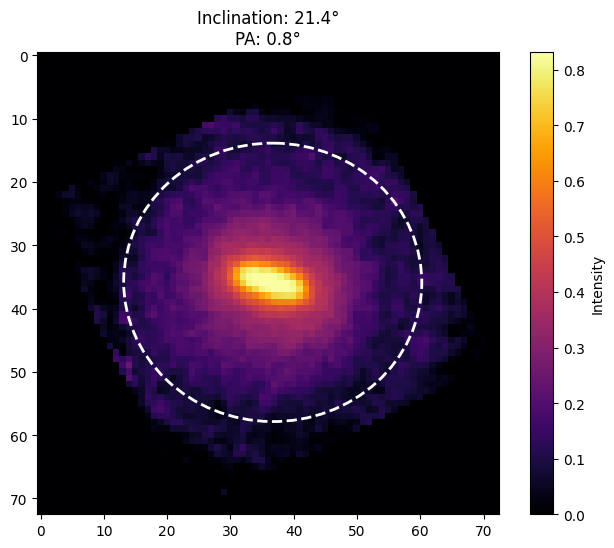

In [84]:
stats_rot = pest.estimate_geometry_weighted(rotated_image)
pest.visualize_results(stats_rot)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.023447760334539].


Cropped shape: (67, 67, 3)


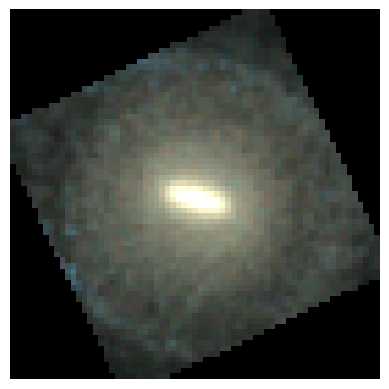

In [85]:
MARGIN = 10
croped_image = pest.crop_quadratic(rotated_image, stats_rot["centroid"], stats_rot["major_axis"] + MARGIN)
print(f"Cropped shape: {croped_image.shape}")

plt.imshow(croped_image)
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.012787122938803].


Scaled shape: (128, 128, 3)


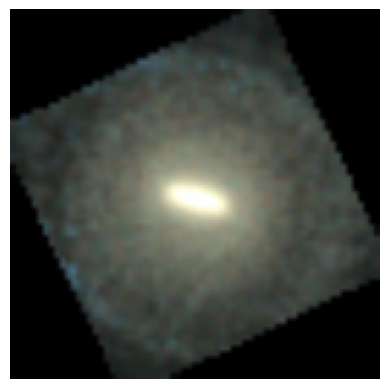

In [86]:
from skimage.transform import resize

scaled_image = resize(croped_image, (128, 128), anti_aliasing=True)
print(f"Scaled shape: {scaled_image.shape}")

plt.imshow(scaled_image)
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.012787122938803].


Canonicalized shape: (128, 128, 3)


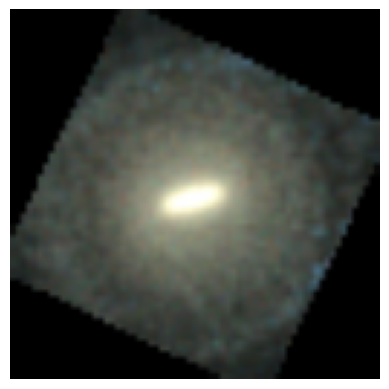

In [87]:
canonicalized_image = pest.reflectional_invariance(scaled_image)
print(f"Canonicalized shape: {canonicalized_image.shape}")

plt.imshow(canonicalized_image)
plt.axis("off")
plt.show()